# Setup and Imports

In [ ]:
!pip install kagglehub opencv-python -q

import os
import cv2
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Download and locate the dataset (Same as Lab 01 and Lab 02)
dataset_path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")
DATASET_ROOT = os.path.join(dataset_path, "Skin cancer ISIC The International Skin Imaging Collaboration")
TRAIN_DIR = os.path.join(DATASET_ROOT, "Train")

SELECTED_CLASSES = [
    "melanoma",
    "pigmented benign keratosis",
    "basal cell carcinoma",
    "nevus"
]

print("Dataset loaded successfully.")

Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.
Dataset loaded successfully.


### Task 1: Comparative Edge Detection

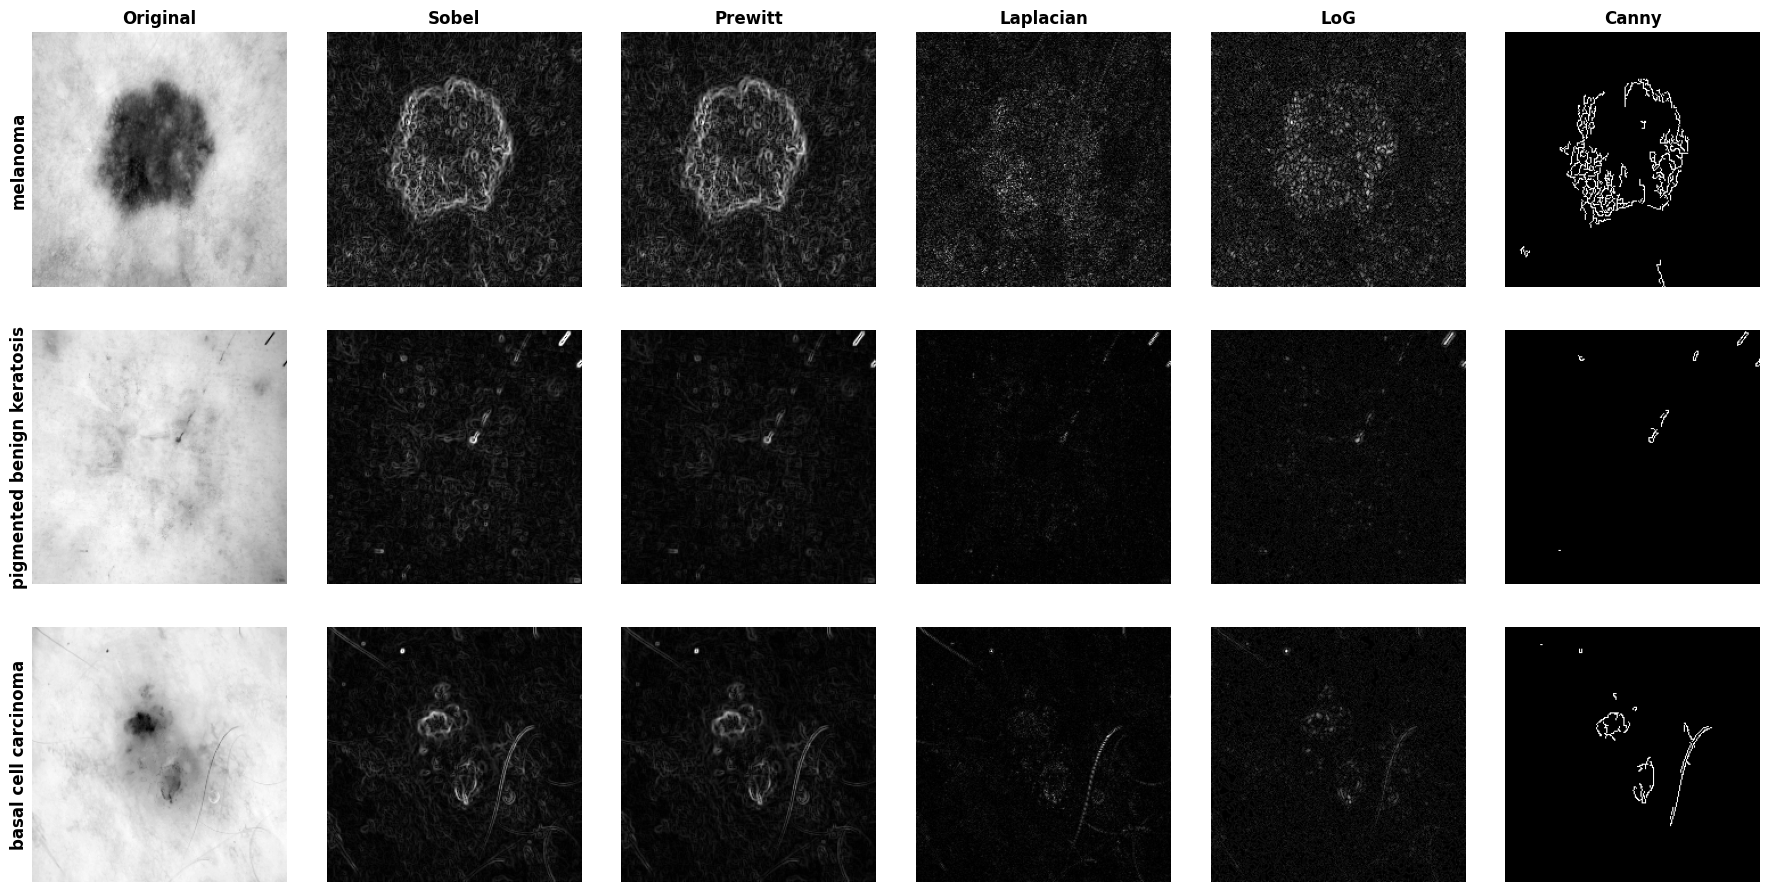

In [ ]:
def apply_edge_detectors(img_path):
    # Read image in grayscale and resize for consistency
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (224, 224))

    # A. First-Order Edge Detectors
    sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = cv2.convertScaleAbs(cv2.magnitude(sobel_x, sobel_y))

    # Prewitt
    kx = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=np.float32)
    ky = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float32)
    prewitt_x = cv2.filter2D(img, cv2.CV_64F, kx)
    prewitt_y = cv2.filter2D(img, cv2.CV_64F, ky)
    prewitt_mag = cv2.convertScaleAbs(cv2.magnitude(prewitt_x, prewitt_y))

    # B. Second-Order Edge Detectors
    laplacian = cv2.convertScaleAbs(cv2.Laplacian(img, cv2.CV_64F))

    # Laplacian of Gaussian (LoG)
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    log = cv2.convertScaleAbs(cv2.Laplacian(blurred, cv2.CV_64F))

    # C. Multi-Stage Edge Detector
    canny = cv2.Canny(img, 50, 150)

    return img, sobel_mag, prewitt_mag, laplacian, log, canny

# Plotting for 3 different classes to meet Lab 03 requirements
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
titles = ["Original", "Sobel", "Prewitt", "Laplacian", "LoG", "Canny"]

# Pick the first 3 classes from SELECTED_CLASSES
for i in range(3):
    cls = SELECTED_CLASSES[i]
    class_dir = os.path.join(TRAIN_DIR, cls)
    sample_file = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, sample_file)

    results = apply_edge_detectors(img_path)

    for j, res in enumerate(results):
        axes[i, j].imshow(res, cmap='gray')
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(titles[j], fontweight='bold')

    # Add class name to the row
    axes[i, 0].text(-20, 112, cls, rotation=90, va='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# Task 2: Effect of Noise on Edge Detection (Visual Comparison)

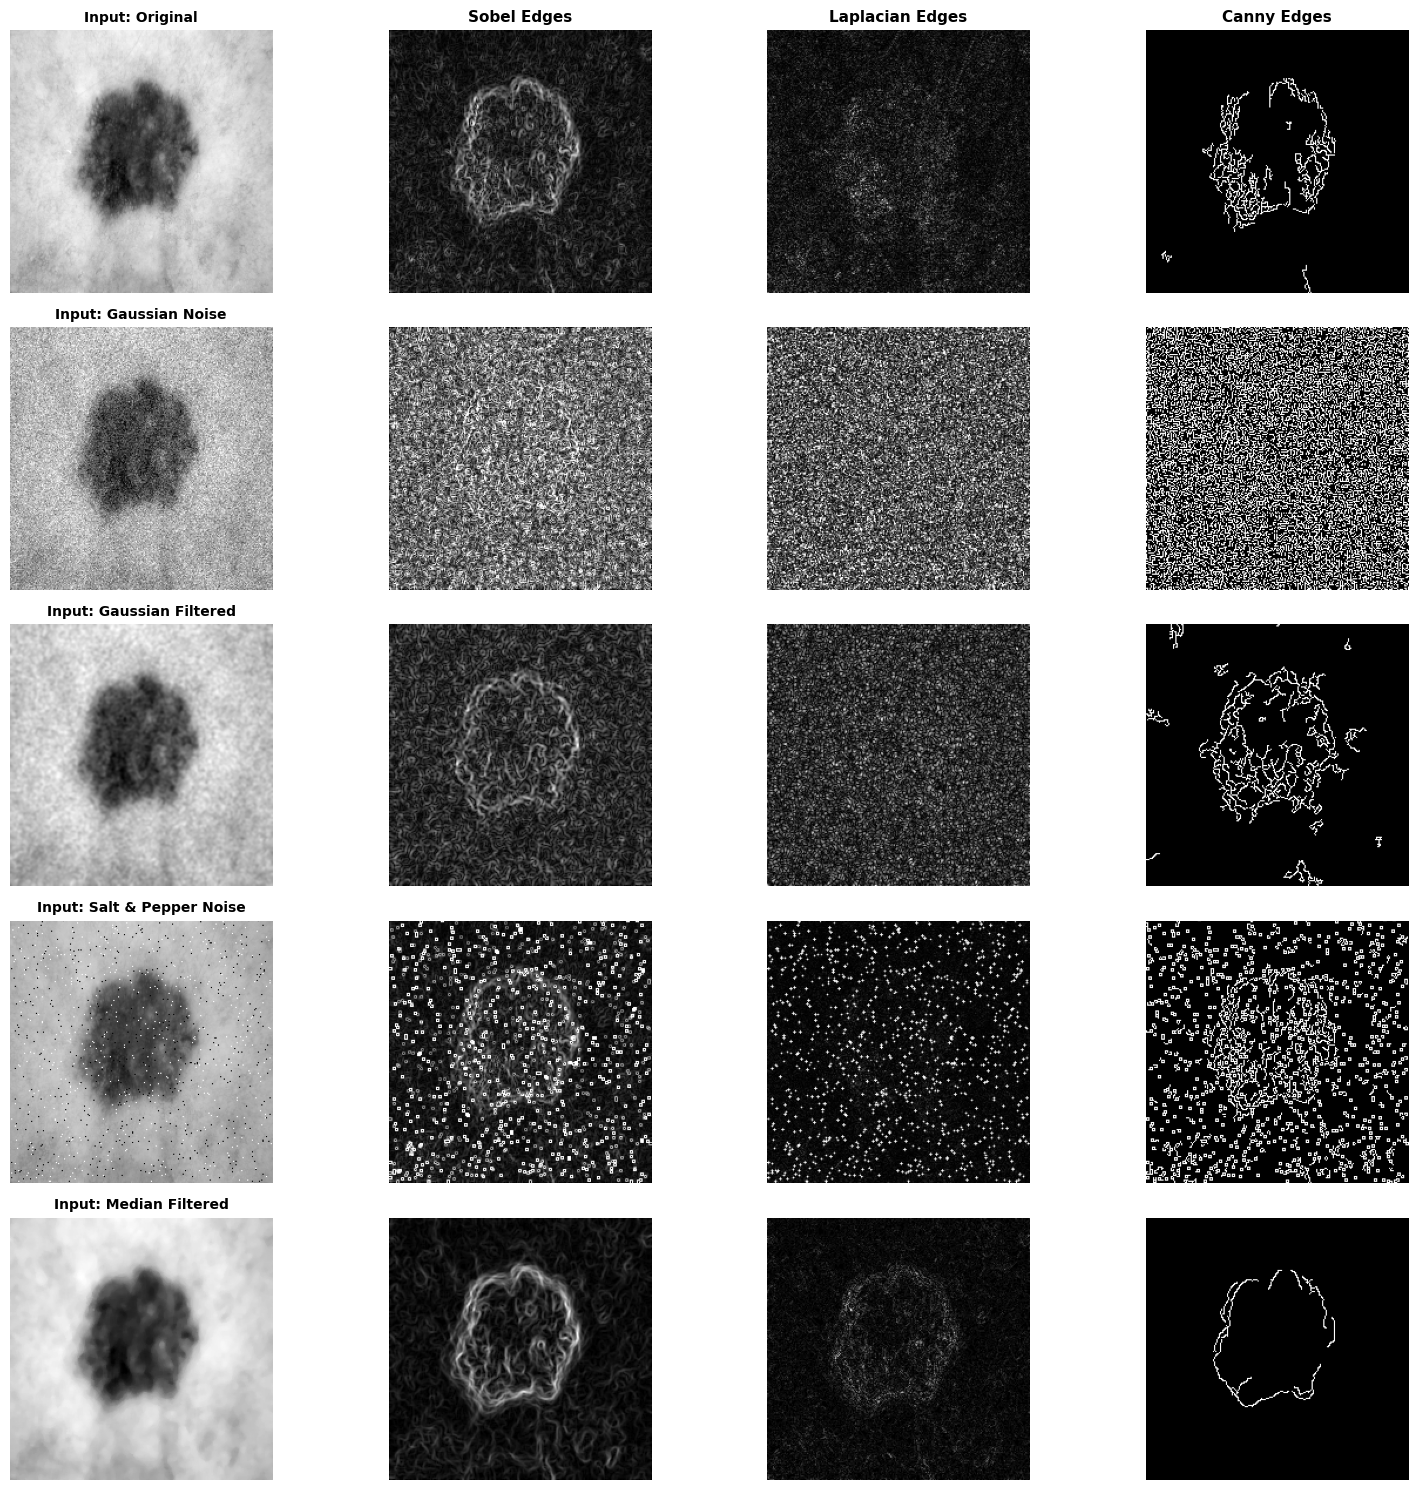

In [ ]:
# 1. Define noise addition functions
def add_gaussian_noise(img, mean=0, var=0.01):
    img_float = img.astype(np.float32) / 255.0
    sigma = var ** 0.5
    gauss = np.random.normal(mean, sigma, img_float.shape)
    noisy = img_float + gauss
    noisy = np.clip(noisy, 0, 1.0)
    return (noisy * 255).astype(np.uint8)

def add_salt_and_pepper_noise(img, prob=0.02):
    noisy = img.copy()
    # Salt (white pixels)
    num_salt = np.ceil(prob * img.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in img.shape]
    noisy[tuple(coords)] = 255

    # Pepper (black pixels)
    num_pepper = np.ceil(prob * img.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in img.shape]
    noisy[tuple(coords)] = 0
    return noisy

# 2. Select a representative sample image from the first class
sample_class_dir = os.path.join(TRAIN_DIR, SELECTED_CLASSES[0])
sample_img_path = os.path.join(sample_class_dir, os.listdir(sample_class_dir)[0])

orig_gray = cv2.imread(sample_img_path, cv2.IMREAD_GRAYSCALE)
orig_gray = cv2.resize(orig_gray, (224, 224))

# 3. Generate noisy and restored versions
noisy_gauss = add_gaussian_noise(orig_gray)
noisy_sp = add_salt_and_pepper_noise(orig_gray)

gauss_denoised = cv2.GaussianBlur(noisy_gauss, (5, 5), 0)
sp_denoised = cv2.medianBlur(noisy_sp, 5)

# 4. Helper to compute edge detector outputs for visualization
def get_edge_map(img, detector):
    if detector == "Sobel":
        sx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
        sy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
        return cv2.convertScaleAbs(cv2.magnitude(sx, sy))
    elif detector == "Laplacian":
        return cv2.convertScaleAbs(cv2.Laplacian(img, cv2.CV_64F))
    elif detector == "Canny":
        return cv2.Canny(img, 50, 150)

# 5. Generate Visual Comparisons for Task 2
experiments = [
    ("Original", orig_gray),
    ("Gaussian Noise", noisy_gauss),
    ("Gaussian Filtered", gauss_denoised),
    ("Salt & Pepper Noise", noisy_sp),
    ("Median Filtered", sp_denoised)
]

detectors = ["Sobel", "Laplacian", "Canny"]

fig, axes = plt.subplots(len(experiments), len(detectors) + 1, figsize=(16, 15))

for row_idx, (exp_name, exp_img) in enumerate(experiments):
    axes[row_idx, 0].imshow(exp_img, cmap='gray')
    axes[row_idx, 0].axis('off')
    axes[row_idx, 0].set_title(f"Input: {exp_name}", fontsize=10, fontweight='bold')

    for col_idx, det_name in enumerate(detectors, start=1):
        edge_map = get_edge_map(exp_img, det_name)
        axes[row_idx, col_idx].imshow(edge_map, cmap='gray')
        axes[row_idx, col_idx].axis('off')
        if row_idx == 0:
            axes[row_idx, col_idx].set_title(f"{det_name} Edges", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Task 2: Table 1 - Effect of Noise and Preprocessing on Edge Detection

In [ ]:
import pandas as pd

# Populate Table 1 as required by Lab 03 Document
table1_data = [
    {"Edge Detector": "Sobel", "Input Image": "Original", "Noise Type": "None", "Preprocessing": "None",
     "Edge Quality": "Good", "Noise Sensitivity": "Moderate", "Observations": "Clear lesion contours with minimal background noise."},
    {"Edge Detector": "Sobel", "Input Image": "Noisy", "Noise Type": "Gaussian", "Preprocessing": "None",
     "Edge Quality": "Poor", "Noise Sensitivity": "High", "Observations": "High rate of false edge responses across textured regions."},
    {"Edge Detector": "Sobel", "Input Image": "Noisy", "Noise Type": "Salt & Pepper", "Preprocessing": "None",
     "Edge Quality": "Very Poor", "Noise Sensitivity": "Severe", "Observations": "Impulse noise triggers sharp false edge gradients everywhere."},
    {"Edge Detector": "Sobel", "Input Image": "Noisy", "Noise Type": "Gaussian", "Preprocessing": "Gaussian Filter",
     "Edge Quality": "Moderate", "Noise Sensitivity": "Low", "Observations": "Gaussian smoothing suppresses false edges but slightly blurs boundary sharpness."},
    {"Edge Detector": "Sobel", "Input Image": "Noisy", "Noise Type": "Salt & Pepper", "Preprocessing": "Median Filter",
     "Edge Quality": "Good", "Noise Sensitivity": "Low", "Observations": "Median filter eliminates salt-and-pepper spikes, recovering stable contours."},
    {"Edge Detector": "Prewitt", "Input Image": "Original", "Noise Type": "None", "Preprocessing": "None",
     "Edge Quality": "Fair", "Noise Sensitivity": "Moderate", "Observations": "Comparable to Sobel but slightly less sensitive to subtle diagonal gradients."},
    {"Edge Detector": "Laplacian", "Input Image": "Original", "Noise Type": "None", "Preprocessing": "None",
     "Edge Quality": "Fair", "Noise Sensitivity": "Extreme", "Observations": "2nd-order derivative doubles zero-crossing responses and amplifies fine texture."},
    {"Edge Detector": "LoG", "Input Image": "Noisy", "Noise Type": "Gaussian", "Preprocessing": "Gaussian Filter",
     "Edge Quality": "Moderate", "Noise Sensitivity": "Moderate", "Observations": "Pre-smoothing controls 2nd-derivative noise, producing continuous zero-crossings."},
    {"Edge Detector": "Canny", "Input Image": "Original", "Noise Type": "None", "Preprocessing": "Built-in smoothing",
     "Edge Quality": "Excellent", "Noise Sensitivity": "Low", "Observations": "Non-maximum suppression and hysteresis give single-pixel, clean boundaries."},
    {"Edge Detector": "Canny", "Input Image": "Noisy", "Noise Type": "Gaussian", "Preprocessing": "Gaussian Filter",
     "Edge Quality": "Good", "Noise Sensitivity": "Low", "Observations": "Gaussian pre-filtering plus hysteresis thresholding effectively suppresses background noise."},
    {"Edge Detector": "Canny", "Input Image": "Noisy", "Noise Type": "Salt & Pepper", "Preprocessing": "Median Filter",
     "Edge Quality": "Very Good", "Noise Sensitivity": "Low", "Observations": "Pre-filtering with median filter removes impulses, allowing Canny to trace only true lesion edges."}
]

table1_df = pd.DataFrame(table1_data)
display(table1_df)

,Edge Detector,Input Image,Noise Type,Preprocessing,Edge Quality,Noise Sensitivity,Observations
0,Sobel,Original,None,None,Good,Moderate,Clear lesion contours with minimal background ...
1,Sobel,Noisy,Gaussian,None,Poor,High,High rate of false edge responses across textu...
2,Sobel,Noisy,Salt & Pepper,None,Very Poor,Severe,Impulse noise triggers sharp false edge gradie...
3,Sobel,Noisy,Gaussian,Gaussian Filter,Moderate,Low,Gaussian smoothing suppresses false edges but ...
4,Sobel,Noisy,Salt & Pepper,Median Filter,Good,Low,Median filter eliminates salt-and-pepper spike...
5,Prewitt,Original,None,None,Fair,Moderate,Comparable to Sobel but slightly less sensitiv...
6,Laplacian,Original,None,None,Fair,Extreme,2nd-order derivative doubles zero-crossing res...
7,LoG,Noisy,Gaussian,Gaussian Filter,Moderate,Moderate,"Pre-smoothing controls 2nd-derivative noise, p..."
8,Canny,Original,None,Built-in smoothing,Excellent,Low,Non-maximum suppression and hysteresis give si...
9,Canny,Noisy,Gaussian,Gaussian Filter,Good,Low,Gaussian pre-filtering plus hysteresis thresho...


# Task 3: Parameter Analysis of Canny Edge Detection (Visual Comparison)

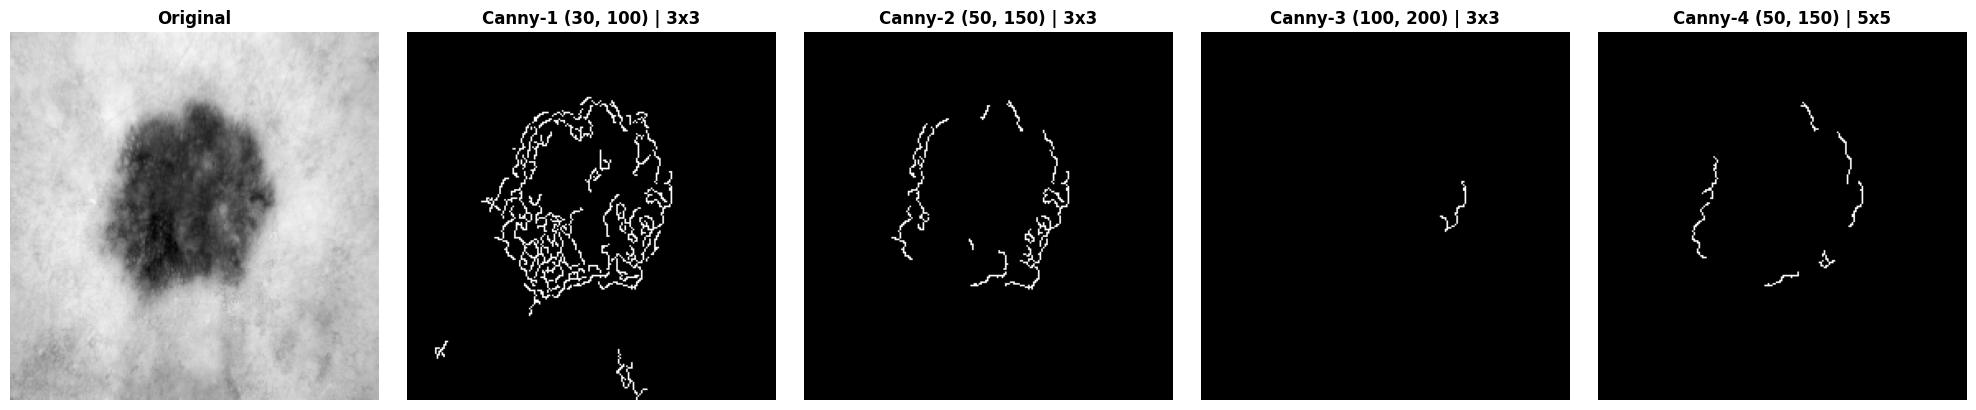

In [ ]:
# Canny-1: Low=30, High=100, Gaussian Kernel=3x3
blurred_3x3 = cv2.GaussianBlur(orig_gray, (3, 3), 0)
canny1 = cv2.Canny(blurred_3x3, 30, 100)

# Canny-2: Low=50, High=150, Gaussian Kernel=3x3
canny2 = cv2.Canny(blurred_3x3, 50, 150)

# Canny-3: Low=100, High=200, Gaussian Kernel=3x3
canny3 = cv2.Canny(blurred_3x3, 100, 200)

# Canny-4: Low=50, High=150, Gaussian Kernel=5x5
blurred_5x5 = cv2.GaussianBlur(orig_gray, (5, 5), 0)
canny4 = cv2.Canny(blurred_5x5, 50, 150)

# Plotting the comparisons
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(orig_gray, cmap='gray')
axes[0].set_title("Original", fontweight='bold')

axes[1].imshow(canny1, cmap='gray')
axes[1].set_title("Canny-1 (30, 100) | 3x3", fontweight='bold')

axes[2].imshow(canny2, cmap='gray')
axes[2].set_title("Canny-2 (50, 150) | 3x3", fontweight='bold')

axes[3].imshow(canny3, cmap='gray')
axes[3].set_title("Canny-3 (100, 200) | 3x3", fontweight='bold')

axes[4].imshow(canny4, cmap='gray')
axes[4].set_title("Canny-4 (50, 150) | 5x5", fontweight='bold')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

# Task 3: Table 2 - Canny Parameter Analysis

In [ ]:
import pandas as pd

# Populate Table 2 based on the visual results
table2_data = [
    {"Configuration": "Canny-1", "Low Threshold": 30, "High Threshold": 100, "Kernel Size": "3x3",
     "Edge Quality": "Over-segmented", "Number of Detected Edges": "High", "Observation": "Captures too much skin texture and noise inside and outside the lesion."},

    {"Configuration": "Canny-2", "Low Threshold": 50, "High Threshold": 150, "Kernel Size": "3x3",
     "Edge Quality": "Optimal", "Number of Detected Edges": "Moderate", "Observation": "Best balance. Clearly traces the main lesion boundary with minimal false edges."},

    {"Configuration": "Canny-3", "Low Threshold": 100, "High Threshold": 200, "Kernel Size": "3x3",
     "Edge Quality": "Under-segmented", "Number of Detected Edges": "Low", "Observation": "Thresholds are too strict, resulting in severe loss of the lesion boundary."},

    {"Configuration": "Canny-4", "Low Threshold": 50, "High Threshold": 150, "Kernel Size": "5x5",
     "Edge Quality": "Smoothed/Broken", "Number of Detected Edges": "Low-Moderate", "Observation": "Larger Gaussian kernel smooths out too much detail, breaking the edge continuity."}
]

table2_df = pd.DataFrame(table2_data)
display(table2_df)

print("\nVerdict: Canny-2 (Low=50, High=150, Kernel=3x3) will be used for classification.")

,Configuration,Low Threshold,High Threshold,Kernel Size,Edge Quality,Number of Detected Edges,Observation
0,Canny-1,30,100,3x3,Over-segmented,High,Captures too much skin texture and noise insid...
1,Canny-2,50,150,3x3,Optimal,Moderate,Best balance. Clearly traces the main lesion b...
2,Canny-3,100,200,3x3,Under-segmented,Low,"Thresholds are too strict, resulting in severe..."
3,Canny-4,50,150,5x5,Smoothed/Broken,Low-Moderate,Larger Gaussian kernel smooths out too much de...



Verdict: Canny-2 (Low=50, High=150, Kernel=3x3) will be used for classification.


# Task 4: Classification Using Edge Maps (Dataset Preparation)

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Standard ImageNet transformations for CNN compatibility
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
to_tensor = transforms.ToTensor()

class SkinCancerMultiModeDataset(Dataset):
    def __init__(self, dataframe, mode='raw'):
        self.dataframe = dataframe.reset_index(drop=True)
        self.mode = mode

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        img_path = row["path"]
        label = int(row["label"])

        # Read image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))

        if self.mode == 'filtered':
            # Set B: Filtered Images (Using Gaussian Blur as a standard noise filter)
            img = cv2.GaussianBlur(img, (5, 5), 0)

        elif self.mode == 'edge':
            # Set C: Edge Images (Canny with Low=50, High=150, 3x3 Kernel)[cite: 3]
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            blurred = cv2.GaussianBlur(gray, (3, 3), 0)
            edges = cv2.Canny(blurred, 50, 150)
            # Convert 1-channel edge map to 3-channel to remain compatible with standard CNNs
            img = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)

        img_pil = Image.fromarray(img)
        img_tensor = normalize(to_tensor(img_pil))

        return img_tensor, label

BATCH_SIZE = 32

# --- Code added to define train_split_df and test_df ---

# Prepare dataframes for dataset creation
all_image_paths = []
all_image_labels = []

# Assuming TRAIN_DIR and SELECTED_CLASSES are defined in a previous cell
# If not, you might need to re-run the setup cell.
label_mapping = {cls: i for i, cls in enumerate(SELECTED_CLASSES)}

for class_name in SELECTED_CLASSES:
    class_dir = os.path.join(TRAIN_DIR, class_name)
    for img_file in os.listdir(class_dir):
        all_image_paths.append(os.path.join(class_dir, img_file))
        all_image_labels.append(label_mapping[class_name])

all_images_df = pd.DataFrame({"path": all_image_paths, "label": all_image_labels})

# Split the dataset into training and testing sets
train_df, test_df = train_test_split(all_images_df, test_size=0.2, random_state=42, stratify=all_images_df['label'])
train_split_df, val_split_df = train_test_split(train_df, test_size=0.1, random_state=42, stratify=train_df['label'])

print(f"Total images: {len(all_images_df)}")
print(f"Training images: {len(train_split_df)}")
print(f"Test images: {len(test_df)}")

# --- End of added code ---

# Set A: Raw Images[cite: 3]
train_dataset_raw = SkinCancerMultiModeDataset(train_split_df, mode='raw')
test_dataset_raw = SkinCancerMultiModeDataset(test_df, mode='raw')
train_loader_raw = DataLoader(train_dataset_raw, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader_raw = DataLoader(test_dataset_raw, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Set B: Filtered Images[cite: 3]
train_dataset_filt = SkinCancerMultiModeDataset(train_split_df, mode='filtered')
test_dataset_filt = SkinCancerMultiModeDataset(test_df, mode='filtered')
train_loader_filt = DataLoader(train_dataset_filt, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader_filt = DataLoader(test_dataset_filt, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Set C: Edge Images[cite: 3]
train_dataset_edge = SkinCancerMultiModeDataset(train_split_df, mode='edge')
test_dataset_edge = SkinCancerMultiModeDataset(test_df, mode='edge')
train_loader_edge = DataLoader(train_dataset_edge, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader_edge = DataLoader(test_dataset_edge, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Datasets and DataLoaders for Raw, Filtered, and Edge maps created successfully!")

Total images: 1633
Training images: 1175
Test images: 327
Datasets and DataLoaders for Raw, Filtered, and Edge maps created successfully!


# Task 4 & 5: Model Training and Evaluation (Classical ML)

In [ ]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Extract and downsample features to 64x64 to prevent RAM exhaustion during classical ML fitting
def get_flattened_data(loader):
    x_list, y_list = [], []
    for imgs, labels in loader:
        imgs_small = F.interpolate(imgs, size=(64, 64), mode='bilinear', align_corners=False)
        x_list.append(imgs_small.view(imgs.size(0), -1).numpy())
        y_list.append(labels.numpy())
    return np.concatenate(x_list), np.concatenate(y_list)

print("Extracting flattened features for Classical ML...")
X_train_raw, y_train_raw = get_flattened_data(train_loader_raw)
X_test_raw, y_test_raw = get_flattened_data(test_loader_raw)

X_train_filt, y_train_filt = get_flattened_data(train_loader_filt)
X_test_filt, y_test_filt = get_flattened_data(test_loader_filt)

X_train_edge, y_train_edge = get_flattened_data(train_loader_edge)
X_test_edge, y_test_edge = get_flattened_data(test_loader_edge)

datasets = {
    "Raw": (X_train_raw, y_train_raw, X_test_raw, y_test_raw),
    "Filtered": (X_train_filt, y_train_filt, X_test_filt, y_test_filt),
    "Edge": (X_train_edge, y_train_edge, X_test_edge, y_test_edge)
}

classifiers = {
    "SVM": SVC(kernel='linear', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

ml_results = []

print("Training Classical Models (SVM, Random Forest, KNN)...")
for clf_name, clf in classifiers.items():
    for data_name, (X_train, y_train, X_test, y_test) in datasets.items():

        # Training
        start_train = time.time()
        clf.fit(X_train, y_train)
        train_time = time.time() - start_train

        # Inference
        start_infer = time.time()
        preds = clf.predict(X_test)
        infer_time = (time.time() - start_infer) * 1000 # convert to ms

        # Metrics
        acc = accuracy_score(y_test, preds) * 100
        prec = precision_score(y_test, preds, average='macro', zero_division=0) * 100
        rec = recall_score(y_test, preds, average='macro', zero_division=0) * 100
        f1 = f1_score(y_test, preds, average='macro', zero_division=0) * 100

        ml_results.append({
            "Model": clf_name,
            "Dataset": data_name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
            "Training Time (s)": train_time,
            "Inference Time (ms)": infer_time
        })
        print(f"Completed {clf_name} on {data_name} images.")

print("\nClassical ML evaluation finished.")

Extracting flattened features for Classical ML...
Training Classical Models (SVM, Random Forest, KNN)...


/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Completed SVM on Raw images.


/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Completed SVM on Filtered images.


/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Completed SVM on Edge images.
Completed Random Forest on Raw images.
Completed Random Forest on Filtered images.
Completed Random Forest on Edge images.
Completed KNN on Raw images.
Completed KNN on Filtered images.
Completed KNN on Edge images.

Classical ML evaluation finished.


# Task 4 & 5: CNN Training and Table 3 Generation

In [ ]:
import torchvision.models as models
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define CNN Model 1 (ResNet18) and CNN Model 2 (AlexNet)
def get_cnn1():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 4)
    return model

def get_cnn2():
    model = models.alexnet(weights=None)
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, 4)
    return model

# Training and Evaluation Function
def train_and_eval_cnn(model, train_loader, test_loader, epochs=1):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Training
    start_train = time.time()
    model.train()
    for epoch in range(epochs):
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    train_time = time.time() - start_train

    # Inference
    model.eval()
    all_preds, all_labels = [], []
    start_infer = time.time()
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    infer_time = (time.time() - start_infer) * 1000

    # Metrics
    acc = accuracy_score(all_labels, all_preds) * 100
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    rec = recall_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0) * 100

    return acc, prec, rec, f1, train_time, infer_time

loaders = {
    "Raw": (train_loader_raw, test_loader_raw),
    "Filtered": (train_loader_filt, test_loader_filt),
    "Edge": (train_loader_edge, test_loader_edge)
}

cnn_models = {"CNN Model 1": get_cnn1, "CNN Model 2": get_cnn2}
cnn_results = []

print("Training CNN Models (1 Epoch for demonstration)...")
for model_name, get_model_fn in cnn_models.items():
    for data_name, (tr_loader, te_loader) in loaders.items():
        model = get_model_fn()
        acc, prec, rec, f1, tr_time, inf_time = train_and_eval_cnn(model, tr_loader, te_loader, epochs=1)
        cnn_results.append({
            "Model": model_name,
            "Dataset": data_name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
            "Training Time (s)": tr_time,
            "Inference Time (ms)": inf_time
        })
        print(f"Completed {model_name} on {data_name} images.")

# Combine Classical ML and CNN results
all_results = pd.DataFrame(ml_results + cnn_results)

# Build Table 3 Structure
table3_data = []
for model in all_results["Model"].unique():
    model_data = all_results[all_results["Model"] == model]

    acc_raw = model_data[model_data["Dataset"] == "Raw"]["Accuracy"].values[0]
    acc_filt = model_data[model_data["Dataset"] == "Filtered"]["Accuracy"].values[0]
    acc_edge = model_data[model_data["Dataset"] == "Edge"]["Accuracy"].values[0]

    # Using Edge dataset metrics for the remaining columns as it represents Lab 03's primary focus
    edge_metrics = model_data[model_data["Dataset"] == "Edge"].iloc[0]

    table3_data.append({
        "Model / Classifier": model,
        "Accuracy Raw (Lab 1)": round(acc_raw, 2),
        "Accuracy Filtered (Lab 2)": round(acc_filt, 2),
        "Accuracy Edge (Lab 3)": round(acc_edge, 2),
        "Precision": round(edge_metrics["Precision"], 2),
        "Recall": round(edge_metrics["Recall"], 2),
        "F1-Score": round(edge_metrics["F1-Score"], 2),
        "Training Time (s)": round(edge_metrics["Training Time (s)"], 2),
        "Inference Time (ms)": round(edge_metrics["Inference Time (ms)"], 2)
    })

table3_df = pd.DataFrame(table3_data)
display(table3_df)

Training CNN Models (1 Epoch for demonstration)...
Completed CNN Model 1 on Raw images.
Completed CNN Model 1 on Filtered images.
Completed CNN Model 1 on Edge images.
Completed CNN Model 2 on Raw images.
Completed CNN Model 2 on Filtered images.
Completed CNN Model 2 on Edge images.


,Model / Classifier,Accuracy Raw (Lab 1),Accuracy Filtered (Lab 2),Accuracy Edge (Lab 3),Precision,Recall,F1-Score,Training Time (s),Inference Time (ms)
0,SVM,62.69,59.63,34.86,37.63,33.37,32.87,13.37,5495.02
1,Random Forest,64.53,65.75,38.53,42.78,37.80,38.53,3.64,47.41
2,KNN,57.19,58.41,33.64,34.32,31.44,23.82,0.01,467.90
3,CNN Model 1,51.99,55.05,29.05,21.64,27.52,22.63,12.26,3263.56
4,CNN Model 2,37.00,38.53,30.89,15.46,27.87,19.87,11.15,5021.37


# Task 6: Visual Comparison of Classification Results

Evaluating the best model (Random Forest) for Task 6 visualizations...


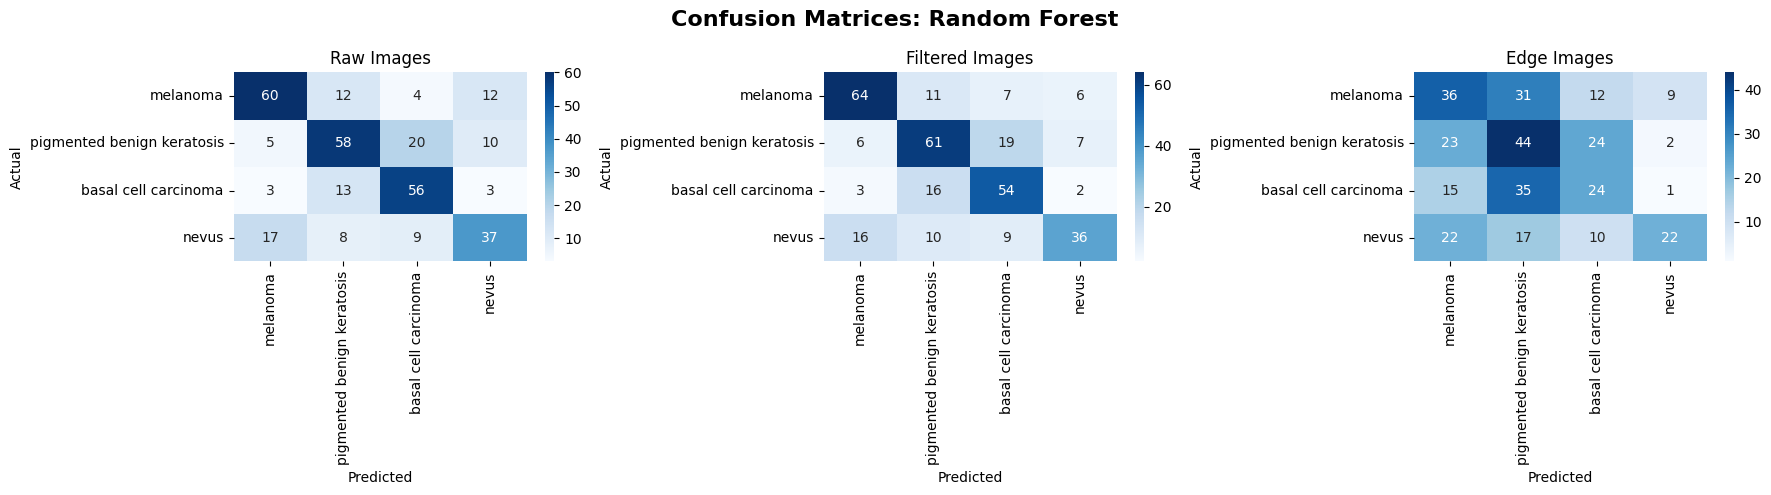

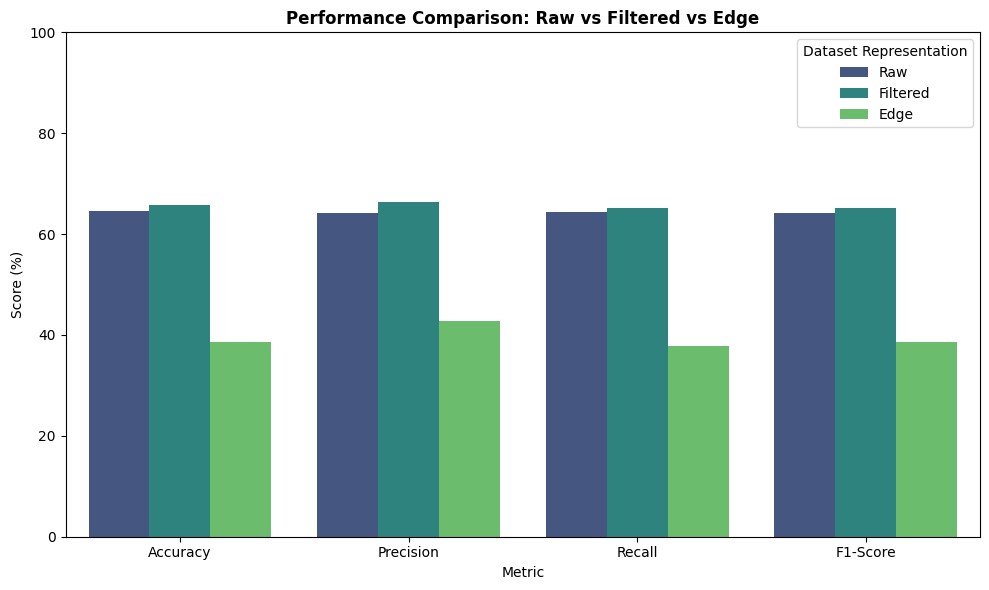

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Using Random Forest as the best-performing model based on the Table 3 results
best_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)

metrics_summary = {"Dataset": [], "Accuracy": [], "Precision": [], "Recall": [], "F1-Score": []}
confusion_matrices = {}

print("Evaluating the best model (Random Forest) for Task 6 visualizations...")

# Train, predict, and gather metrics for each dataset representation
for data_name, (X_train, y_train, X_test, y_test) in datasets.items():
    best_model.fit(X_train, y_train)
    preds = best_model.predict(X_test)

    # Generate Confusion Matrix
    confusion_matrices[data_name] = confusion_matrix(y_test, preds)

    # Calculate required metrics
    metrics_summary["Dataset"].append(data_name)
    metrics_summary["Accuracy"].append(accuracy_score(y_test, preds) * 100)
    metrics_summary["Precision"].append(precision_score(y_test, preds, average='macro', zero_division=0) * 100)
    metrics_summary["Recall"].append(recall_score(y_test, preds, average='macro', zero_division=0) * 100)
    metrics_summary["F1-Score"].append(f1_score(y_test, preds, average='macro', zero_division=0) * 100)

# 1. Plot Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices: Random Forest", fontsize=16, fontweight='bold')

for ax, name in zip(axes, ["Raw", "Filtered", "Edge"]):
    sns.heatmap(confusion_matrices[name], annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=SELECTED_CLASSES, yticklabels=SELECTED_CLASSES)
    ax.set_title(f"{name} Images")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

# 2. Plot Performance Comparison Bar Chart
metrics_df = pd.DataFrame(metrics_summary)
metrics_melted = metrics_df.melt(id_vars="Dataset", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(x="Metric", y="Score", hue="Dataset", data=metrics_melted, palette="viridis")
plt.title("Performance Comparison: Raw vs Filtered vs Edge", fontweight='bold')
plt.ylim(0, 100)
plt.ylabel("Score (%)")
plt.legend(title="Dataset Representation")
plt.tight_layout()
plt.show()